# Regressione SVM in Python

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

In [99]:
# Caricamento Dati 

data = fetch_california_housing()
X = data.data
y = data.target

In [100]:
# Ispezione Dati 

df = pd.DataFrame(X, columns=data.feature_names)
df["MedHouseVal"] = y
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Standardizzazione

In [101]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Definizione Modelli

In [102]:
svr_linear = SVR(kernel="linear", C=1.0, epsilon=5.0)
svr_rbf_eps5 = SVR(kernel="rbf", C=1.0, epsilon=5.0)
svr_rbf_eps20 = SVR(kernel="rbf", C=1.0, epsilon=20.0)

Training e Predizione

In [103]:
svr_linear.fit(X_scaled, y)
y_pred_linear = svr_linear.predict(X_scaled)

svr_rbf_eps5.fit(X_scaled, y)
y_pred_rbf_eps5 = svr_rbf_eps5.predict(X_scaled)

svr_rbf_eps20.fit(X_scaled, y)
y_pred_rbf_eps20 = svr_rbf_eps20.predict(X_scaled)

Metriche 

In [104]:
mse_linear = mean_squared_error(y, y_pred_linear)
r2_linear = r2_score(y, y_pred_linear)

mse_rbf_eps5 = mean_squared_error(y, y_pred_rbf_eps5)
r2_rbf_eps5 = r2_score(y, y_pred_rbf_eps5)

mse_rbf_eps20 = mean_squared_error(y, y_pred_rbf_eps20)
r2_rbf_eps20 = r2_score(y, y_pred_rbf_eps20)



In [105]:
# Print risultati

print("SVR linear")
print(f"MSE: {mse_linear:.4f}")
print(f"R**2: {r2_linear:.4f}\n")

print("SVR rbf (epsilon=5)")
print(f"MSE: {mse_rbf_eps5:.4f}")
print(f"R² : {r2_rbf_eps5:.4f}\n")

print("SVR rbf (epsilon=20)")
print(f"MSE: {mse_rbf_eps20:.4f}")
print(f"R² : {r2_rbf_eps20:.4f}")

SVR linear
MSE: 1.5880
R**2: -0.1926

SVR rbf (epsilon=5)
MSE: 1.5880
R² : -0.1926

SVR rbf (epsilon=20)
MSE: 1.5880
R² : -0.1926


Scelta feature per i plot

In [106]:
feature_index = 0
feature_name = data.feature_names[feature_index]

sort_idx = X_scaled[:, feature_index].argsort()
X_plot = X_scaled[sort_idx, feature_index]

Ordinamento delle predizioni

In [107]:
y_pred_linear_plot = y_pred_linear[sort_idx]
y_pred_rbf_eps5_plot = y_pred_rbf_eps5[sort_idx]
y_pred_rbf_eps20_plot = y_pred_rbf_eps20[sort_idx]

# Plot finale

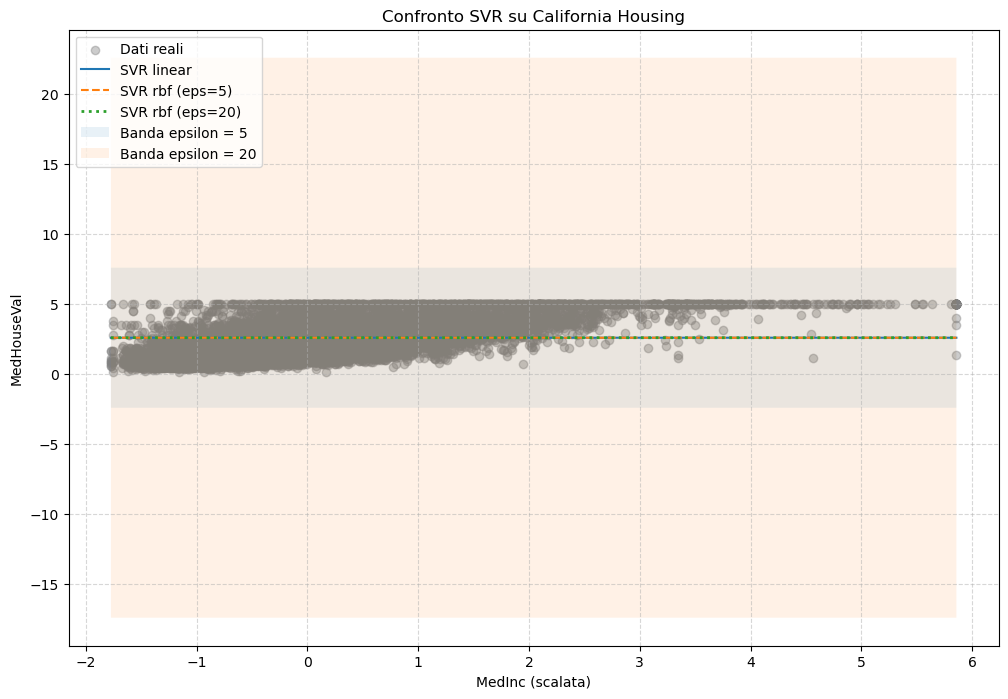

In [108]:
plt.figure(figsize=(12, 8))

plt.scatter(
    X_scaled[:, feature_index], y,
    color="gray", alpha=0.4, label="Dati reali"
)

plt.plot(
    X_plot, y_pred_linear_plot,
    linestyle="-", linewidth=1.5, label="SVR linear"
)

plt.plot(
    X_plot, y_pred_rbf_eps5_plot,
    linestyle="--", linewidth=1.5, label="SVR rbf (eps=5)"
)

plt.plot(
    X_plot, y_pred_rbf_eps20_plot,
    linestyle=":", linewidth=2, label="SVR rbf (eps=20)"
)

plt.fill_between(
    X_plot,
    y_pred_rbf_eps5_plot - 5,
    y_pred_rbf_eps5_plot + 5,
    alpha=0.10,
    label="Banda epsilon = 5"
)

plt.fill_between(
    X_plot,
    y_pred_rbf_eps20_plot - 20,
    y_pred_rbf_eps20_plot + 20,
    alpha=0.10,
    label="Banda epsilon = 20"
)

plt.title("Confronto SVR su California Housing")
plt.xlabel(f"{feature_name} (scalata)")
plt.ylabel("MedHouseVal")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()